# Trabalho Final: Inteligência Artificial
### Sistema Inteligente de Triagem em Pronto-Socorro
---

## 2. Instalação e Importação de Bibliotecas

Vamos usar a biblioteca `pgmpy` (Probabilistic Graphical Models in Python), que facilita a criação e inferência em redes bayesianas.

In [2]:
# Instalação (execute apenas uma vez)
%pip install pgmpy matplotlib networkx numpy pandas

  Using cached pgmpy-1.1.2-py3-none-any.whl.metadata (13 kB)
  Using cached matplotlib-3.11.0-cp314-cp314-win_amd64.whl.metadata (80 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached numpy-2.5.0-cp314-cp314-win_amd64.whl.metadata (6.6 kB)
  Using cached pandas-3.0.3-cp314-cp314-win_amd64.whl.metadata (19 kB)
  Using cached huggingface_hub-1.21.0-py3-none-any.whl.metadata (14 kB)
  Using cached scipy-1.18.0-cp314-cp314-win_amd64.whl.metadata (61 kB)
  Using cached scikit_learn-1.9.0-cp314-cp314-win_amd64.whl.metadata (11 kB)
  Using cached statsmodels-0.14.6-cp314-cp314-win_amd64.whl.metadata (9.8 kB)
  Using cached tqdm-4.68.3-py3-none-any.whl.metadata (57 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached scikit_base-1.0.2-py3-none-any.whl.metadata (8.8 kB)
  Using cached contourpy-1.3.3-cp

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To 

In [3]:
# Importações necessárias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination

# Configuração para visualização
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

c:\Users\guilherme.cirineu\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\guilherme.cirineu\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pgmpy\estimators\__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in v1.3.0. Use `pgmpy.structure_score` instead.
  from .StructureScore import (


---

## 3. Exemplo 1: Sistema de Diagnóstico de Gravidade do Paciente

### Cenário

Vamos modelar um sistema simples de diagnóstico para **Gravidade**.

**Variáveis:**
- **Saturacao**: qual o nível saturação O2?
- **Febre**: pessoa tem febre? Sim/Não
- **PressaoArt**: qual o nível pressão arterial?
- **FreqCard**: qual o nível frequência cardíaca?
- **NivelDor**: qual o nível de dor?

**Estrutura causal:**
```
                Gravidade
               / .. | .. \
Febre Saturacao PressaoArt FreqCard NivelDor
```

Ao fazer a modelagem da rede e construir as probabilidade à priori e à posteriori podemos inferir casos com os sintomas (febre, saturação O2, pressão arterial, frequência cardíaca e nível de dor) **definindo** o nível de Gravidade (Baixa/Média/Alta).

In [5]:
# Passo 1: Definir a estrutura da rede (grafo)
modelo_diagnostico_gravidade = DiscreteBayesianNetwork([
    ('Gravidade', 'Febre'),
    ('Gravidade', 'Saturacao'),
    ('Gravidade', 'PressaoArt'),
    ('Gravidade', 'FreqCard'),
    ('Gravidade', 'NivelDor'),
])

print("Estrutura da rede criada!")
print(f"Nós: {modelo_diagnostico_gravidade.nodes()}")
print(f"Arestas: {modelo_diagnostico_gravidade.edges()}")

Estrutura da rede criada!
Nós: ['Gravidade', 'Febre', 'Saturacao', 'PressaoArt', 'FreqCard', 'NivelDor']
Arestas: [('Gravidade', 'Febre'), ('Gravidade', 'Saturacao'), ('Gravidade', 'PressaoArt'), ('Gravidade', 'FreqCard'), ('Gravidade', 'NivelDor')]


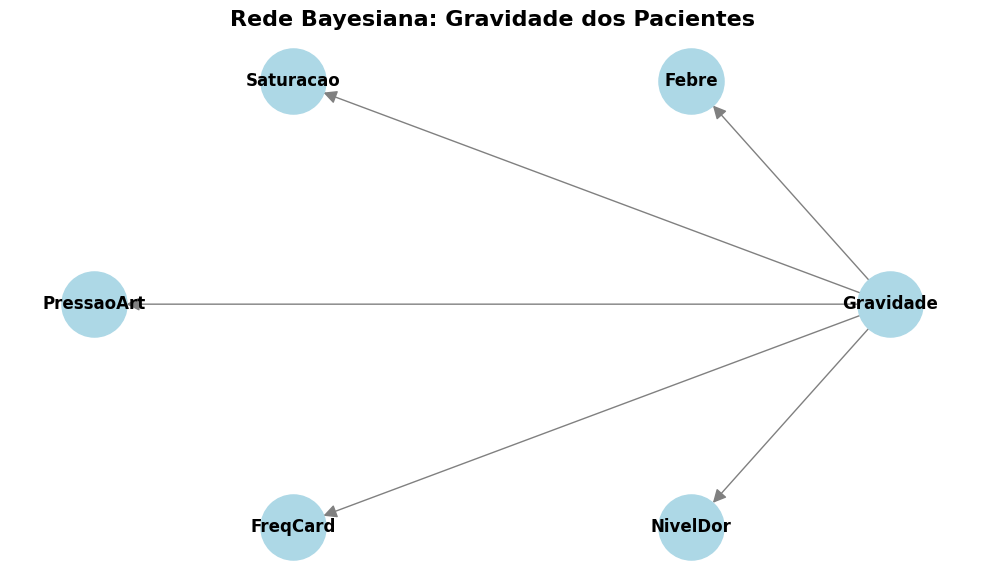

In [ ]:
# Visualizar a estrutura da rede
def visualizar_rede(modelo, titulo="Rede Bayesiana"):
    plt.figure(figsize=(10, 6))
    pos = nx.circular_layout(modelo) # Alterado para circular_layout para maior estabilidade

    # 1. Desenhar os nós
    nx.draw_networkx_nodes(modelo, pos, node_color='lightblue', node_size=2200)

    # 2. Desenhar as arestas (explicitamente sem setas para evitar erros)
    nx.draw_networkx_edges(modelo, pos, edge_color='gray', arrows=True,
                           arrowstyle='-|>', arrowsize=20, node_size=2200)

    # 3. Desenhar os rótulos dos nós
    nx.draw_networkx_labels(modelo, pos, font_size=12, font_weight='bold')

    plt.title(titulo, fontsize=16, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

visualizar_rede(modelo_diagnostico_gravidade, "Rede Bayesiana: Gravidade dos Pacientes")

In [6]:


# Definição de estados possíveis
SATURACAO_STATES = ['Normal', 'Reduzida', 'Critica']
GRAVIDADE_STATES = ['Alta', 'Media', 'Baixa']
FEBRE_STATES = ['Sim', 'Nao']
PRESART_STATES = ['Normal', 'Baixa', 'Alta']
FREQCARD_STATES = ['Normal', 'Baixa', 'Alta']
DOR_STATES = ['Leve', 'Moderada', 'Intensa']



# Passo 2: Definir as Tabelas de Probabilidade Condicional (CPTs)
# CPT para Gravidade (probabilidade a priori)
# P(Gravidade=Baixa) = 0.325 (32,5% dos casos registrados
# na referência são de baixa gravidade )
cpd_gravidade = TabularCPD(
    variable="Gravidade",
    variable_card=3,
    values=[
            [0.325], # P(Gravidade=Baixa)
            [0.491], # P(Gravidade=Média)
            [0.184]  # P(Gravidade=Alta)
            ],
    state_names={
    "Gravidade": GRAVIDADE_STATES
}
)

# CPT para a Saturação de O2 dada a Gravidade 
cpd_saturacao = TabularCPD(
    variable="Saturacao",
    variable_card=3,
    values=[
        [0.10, 0.45, 0.85],  # Normal
        [0.2, 0.5, 0.12],  # Reduzida
        [0.7, 0.05, 0.03],  # Critica
    ],
    evidence=["Gravidade"],
    evidence_card=[3],
    state_names={
        "Gravidade": GRAVIDADE_STATES,
        "Saturacao": SATURACAO_STATES
    }
)

# CPT para a Febre dada a Gravidade
cpd_febre = TabularCPD(
    variable="Febre",
    variable_card=2,
    values=[
        [0.60, 0.35, 0.10],  # Sim
        [0.40, 0.65, 0.90],  # Nao
    ],
    evidence=["Gravidade"],
    evidence_card=[3],
    state_names={
        "Gravidade": GRAVIDADE_STATES,
        "Febre": FEBRE_STATES
    }
)

# CPT para a Pressão Arterial dada a Gravidade
cpd_pressaoArt = TabularCPD(
    variable="PressaoArt",
    variable_card=3,
    values=[
        [0.04, 0.35, 0.38],  # Normal
        [0.21, 0.45, 0.50],  # Baixa
        [0.75, 0.20, 0.12],  # Alta
    ],
    evidence=["Gravidade"],
    evidence_card=[3],
    state_names={
        "PressaoArt": PRESART_STATES ,
        "Gravidade": GRAVIDADE_STATES
    }
)

# CPT para a Frequência Cardíaca dada a Gravidade 
cpd_freqCard = TabularCPD(
    variable="FreqCard",
    variable_card=3,
    values=[
        [0.04, 0.35, 0.38],  # Normal
        [0.21, 0.45, 0.50],  # Baixa
        [0.75, 0.20, 0.12],  # Alta
    ],
    evidence=["Gravidade"],
    evidence_card=[3],
    state_names={
        "Gravidade": GRAVIDADE_STATES,
        "FreqCard": FREQCARD_STATES
    }
)

# CPT para Nível da dor dada a Gravidade
cpd_nivelDor = TabularCPD(
    variable="NivelDor",
    variable_card=3,
    values=[
        [0.03, 0.10, 0.55],  # Leve
        [0.17, 0.6, 0.3],  # Moderada
        [0.8, 0.3, 0.15],  # Intensa
    ],
    evidence=["Gravidade"],
    evidence_card=[3],
    state_names={
        "Gravidade": GRAVIDADE_STATES,
        "NivelDor": DOR_STATES
    }
)

print("CPTs definidas!")

CPTs definidas!


In [7]:
# Passo 3: Adicionar as CPTs ao modelo
modelo_diagnostico_gravidade.add_cpds(cpd_gravidade, cpd_saturacao, cpd_febre, cpd_pressaoArt, cpd_freqCard, cpd_nivelDor)

# Verificar se o modelo está correto
print("Validação do modelo:", modelo_diagnostico_gravidade.check_model())

# Visualizar uma CPT
print("\nCPT da Gravidade:")
print(cpd_gravidade)
print("\nCPT da Febre:")
print(cpd_febre)
print("\nCPT da Saturação de O2:")
print(cpd_saturacao)
print("\nCPT da Pressão Arterial:")
print(cpd_pressaoArt)
print("\nCPT da Frequência Cardíaca:")
print(cpd_freqCard)
print("\nCPT do Nível de Dor:")
print(cpd_nivelDor)


Validação do modelo: True

CPT da Gravidade:
+------------------+-------+
| Gravidade(Alta)  | 0.325 |
+------------------+-------+
| Gravidade(Media) | 0.491 |
+------------------+-------+
| Gravidade(Baixa) | 0.184 |
+------------------+-------+

CPT da Febre:
+------------+-----------------+------------------+------------------+
| Gravidade  | Gravidade(Alta) | Gravidade(Media) | Gravidade(Baixa) |
+------------+-----------------+------------------+------------------+
| Febre(Sim) | 0.6             | 0.35             | 0.1              |
+------------+-----------------+------------------+------------------+
| Febre(Nao) | 0.4             | 0.65             | 0.9              |
+------------+-----------------+------------------+------------------+

CPT da Saturação de O2:
+---------------------+-----------------+------------------+------------------+
| Gravidade           | Gravidade(Alta) | Gravidade(Media) | Gravidade(Baixa) |
+---------------------+-----------------+--------------

### Inferência Probabilística

Agora vamos fazer **inferência** - calcular probabilidades de interesse dado evidências observadas.

In [15]:
# Criar objeto de inferência
inferencia_triagem = VariableElimination(modelo_diagnostico_gravidade)


resultado = inferencia_triagem.query(
    variables=["Febre"]
)

print(f"P(Febre):\n {resultado}")


resultado = inferencia_triagem.query(
    variables=["Gravidade"],
    evidence={"Febre":"Sim", "NivelDor":"Intensa"}
)

print(f"P(Gravidade| Febre=Sim, Dor=Intensa):\n {resultado}\n")

resultado = inferencia_triagem.query(
    variables=["Gravidade"],
    evidence={"Febre":"Nao", "NivelDor":"Intensa", "Saturacao":"Critica"}
)

print(f"P(Gravidade| Febre=Nao, Dor=Intensa, Saturacao=Critica):\n {resultado}\n")



resultado = inferencia_triagem.query(
    variables=["Gravidade"],
    evidence={"Febre":"Sim", "NivelDor":"Intensa", "Saturacao":"Critica", "PressaoArt":"Baixa"}
)

print(f"P(Gravidade| Febre=Sim, Dor=Intensa, Saturacao=Critica, PressaoArt=Baixa):\n {resultado}\n")



resultado = inferencia_triagem.query(
    variables=["Gravidade"],
    evidence={"Febre":"Nao", "NivelDor":"Intensa", "Saturacao":"Normal", "PressaoArt":"Normal", "FreqCard":"Normal"}
)

P(Febre):
 +------------+--------------+
| Febre      |   phi(Febre) |
+============+==============+
| Febre(Sim) |       0.3852 |
+------------+--------------+
| Febre(Nao) |       0.6148 |
+------------+--------------+
P(Gravidade| Febre=Sim, Dor=Intensa):
 +------------------+------------------+
| Gravidade        |   phi(Gravidade) |
+==================+==================+
| Gravidade(Alta)  |           0.7417 |
+------------------+------------------+
| Gravidade(Media) |           0.2451 |
+------------------+------------------+
| Gravidade(Baixa) |           0.0131 |
+------------------+------------------+

P(Gravidade| Febre=Nao, Dor=Intensa, Saturacao=Critica):
 +------------------+------------------+
| Gravidade        |   phi(Gravidade) |
+==================+==================+
| Gravidade(Alta)  |           0.9294 |
+------------------+------------------+
| Gravidade(Media) |           0.0611 |
+------------------+------------------+
| Gravidade(Baixa) |           0.0095 |
+

## Gerar amostras aleatórias com inferências para servir de entrada ao módulo 02

In [17]:
import random

hash_table = {
    "Saturacao": SATURACAO_STATES,
    "Febre": FEBRE_STATES,
    "PressaoArt": PRESART_STATES,
    "FreqCard": FREQCARD_STATES,
    "NivelDor": DOR_STATES
}

def amostras_sinteticas(n=100, inferencia:VariableElimination=None):
    with open("output.txt", 'w') as file:
        count = 0
        for _ in range(n):
            count+=1
            sintomas = ['Febre','Saturacao', 'PressaoArt', 'FreqCard', 'NivelDor',]
            qtd = random.randint(1, len(sintomas))
            valores = random.sample(sintomas, k = qtd)
            evidence = {}
            for sintoma in valores:
                evidence[sintoma] = random.choice(hash_table[sintoma])
            
            result = inferencia.query(
                variables=["Gravidade"],
                evidence=evidence
            )
            file.write(f"\nCaso {count}:\n")
            for variavel, valor in evidence.items():
                file.write(f"{variavel}: {valor}, ")
            file.write(f"\n")      
            for estado, probabilidade in zip(result.state_names["Gravidade"], result.values):
                file.write(f"Gravidade - {estado}: {probabilidade:.4f}, ")
            file.write(f"\n")    
           

amostras_sinteticas(100, inferencia_triagem)

---

## 7. Recursos Adicionais

### Documentação
- **pgmpy**: https://pgmpy.org/
- **Tutorial pgmpy**: https://pgmpy.org/examples/

### Leituras Recomendadas
- Livro: "Probabilistic Graphical Models" - Daphne Koller e Nir Friedman
- Livro: "Artificial Intelligence: A Modern Approach" (Cap. 13) - Russell & Norvig

### Aplicações Práticas
- Diagnóstico médico
- Sistemas de recomendação
- Detecção de fraudes
- Previsão de falhas
- Análise de risco
- Processamento de linguagem natural

---

## 8. Conceitos-Chave

✅ Redes Bayesianas são grafos probabilísticos  
✅ CPTs quantificam relações entre variáveis  
✅ Independência condicional é fundamental  
✅ Inferência permite calcular probabilidades a partir de evidências  
✅ Podemos fazer inferência "para frente" e "para trás"  
